# Baseline Model

Random Forest classifier for fraud detection.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    f1_score, 
    roc_auc_score, 
    precision_score, 
    recall_score,
    RocCurveDisplay
)

sns.set_style('whitegrid')

## Load Data

In [2]:
df = pd.read_csv('../01_data/creditcard.csv')
print(f"Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")

Shape: 284,807 rows, 31 columns


## Prepare Features

In [3]:
# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Scale Amount (Time we'll keep as-is for now)
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])

print(f"Features: {X.shape[1]}")
print(f"Target distribution:\n{y.value_counts()}")

Features: 30
Target distribution:
Class
0    284315
1       492
Name: count, dtype: int64


## Train/Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Keeps fraud ratio same in both sets
)

print(f"Train: {X_train.shape[0]:,} rows")
print(f"Test:  {X_test.shape[0]:,} rows")
print(f"\nTrain fraud ratio: {y_train.mean()*100:.2f}%")
print(f"Test fraud ratio:  {y_test.mean()*100:.2f}%")

Train: 227,845 rows
Test:  56,962 rows

Train fraud ratio: 0.17%
Test fraud ratio:  0.17%


## Train Model

In [5]:
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',  # Handles imbalance
    random_state=42,
    n_jobs=-1  # Use all CPU cores
)

model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## Evaluate Model

In [6]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

print(f"\nF1 Score:    {f1_score(y_test, y_pred):.4f}")
print(f"AUC-ROC:     {roc_auc_score(y_test, y_prob):.4f}")
print(f"Precision:   {precision_score(y_test, y_pred):.4f}")
print(f"Recall:      {recall_score(y_test, y_pred):.4f}")

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962


F1 Score:    0.8391
AUC-ROC:     0.9529
Precision:   0.9605
Recall:      0.7449


### Findings
- **Precision 96%**: When model says fraud, it's right 96% of the time
- **Recall 74%**: Catches 74% of actual fraud cases (misses 26%)
- **AUC-ROC 95%**: Excellent discrimination between classes
- **F1 0.84**: Good balance of precision/recall

## Confusion Matrix

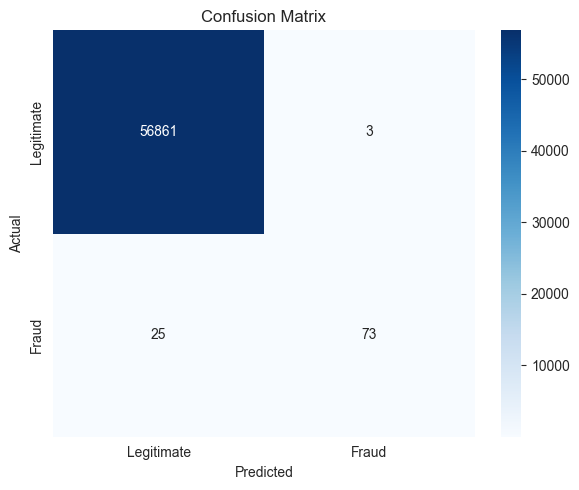

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

## ROC Curve

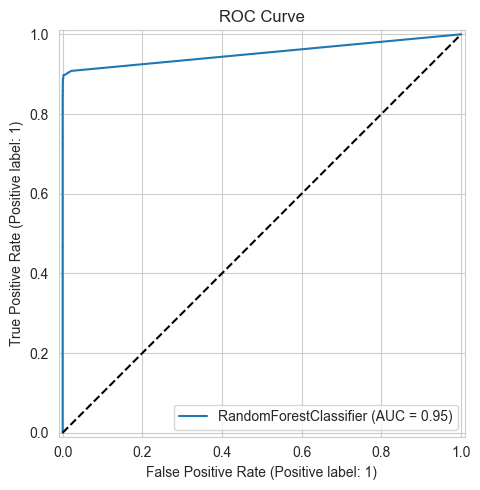

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', label='Random (0.5)')
ax.set_title('ROC Curve')
plt.tight_layout()
plt.show()

## Save Baseline Metrics

In [9]:
baseline_metrics = {
    'f1': f1_score(y_test, y_pred),
    'auc_roc': roc_auc_score(y_test, y_prob),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred)
}

print("Baseline metrics saved:")
for k, v in baseline_metrics.items():
    print(f"  {k}: {v:.4f}")

Baseline metrics saved:
  f1: 0.8391
  auc_roc: 0.9529
  precision: 0.9605
  recall: 0.7449


In [10]:
# Save model for later use on drift data
import joblib
joblib.dump(model, '../02_src/baseline_model.pkl')
joblib.dump(scaler, '../02_src/scaler.pkl')
print("Model and scaler saved.")

Model and scaler saved.
